# Reanalysis Data for Air Quality 

**Part 2 of the AQ Integration module.**

In Part 1, CAMS satellite-and-station analyses were treated as the gridded
context. In Part 2, this notebook proceeds one level deeper and treats **reanalysis** as a
**continuous predictor**: a gap-free, multi-variable description of the
atmospheric state, designed to be fed directly into machine learning models.

Upon completion of this notebook, you will be able to:

1. Open a reanalysis NetCDF file and distinguish it from an observation file.
2. Inspect its grid, time axis, vertical levels, and variable list.
3. Extract values at station locations using **nearest** and **bilinear**
   interpolation.
4. **Intersect** a dense reanalysis time axis (hourly ERA5) onto a sparser
   reference axis (the six-hourly CAMS analysis) so that the two
   can be merged on `(time, location_id)`.
5. Save a tidy long-format CSV with a provenance sidecar.

## Setup

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

In [3]:
_scripts_root = Path.cwd().parent.parent / "scripts"
if not _scripts_root.exists():
    _scripts_root = Path.cwd().parent / "scripts" 
sys.path.insert(0, str(_scripts_root))
sys.path.insert(0, str(_scripts_root / "part2_reanalysis"))

import reanalysis_extract_points as rxp
import reanalysis_to_table as rtt
from utils import _load_data 

## Verifying That the Files Are Downloaded

In [4]:
ERA5_PATH = Path("../../data/era5_meteo_croatia.nc")
CAMS_PATH = Path("../../data/cams_pm25_croatia.nc")  

if not ERA5_PATH.exists():
    raise FileNotFoundError(
        f"\nMissing file: {ERA5_PATH}\n\n"
        "Run from the scripts/ folder:\n"
        "    python download_era5_data.py\n"
    )

if not CAMS_PATH.exists():
    raise FileNotFoundError(
        f"\nMissing file: {CAMS_PATH}\n\n"
        "This file is produced by Part 1 (download_cams_data.py).\n"
    )

print(f"ERA5: {ERA5_PATH}   ({ERA5_PATH.stat().st_size/1024/1024:.1f} MB)")
print(f"CAMS: {CAMS_PATH}   ({CAMS_PATH.stat().st_size/1024/1024:.1f} MB)")

ERA5: ..\..\data\era5_meteo_croatia.nc   (5.4 MB)
CAMS: ..\..\data\cams_pm25_croatia.nc   (9.7 MB)


## Opening the ERA5 File with xarray

In [5]:
era5 = _load_data(ERA5_PATH)
era5

<xarray.Dataset> Size: 12MB
Dimensions:     (valid_time: 720, latitude: 21, longitude: 29)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-06-01 ... 2024-06-30T23:...
    expver      (valid_time) <U4 12kB '0001' '0001' '0001' ... '0001' '0001'
  * latitude    (latitude) float64 168B 47.0 46.75 46.5 ... 42.5 42.25 42.0
  * longitude   (longitude) float64 232B 13.0 13.25 13.5 ... 19.5 19.75 20.0
    number      int64 8B 0
Data variables:
    t2m         (valid_time, latitude, longitude) float32 2MB 274.2 ... 295.1
    d2m         (valid_time, latitude, longitude) float32 2MB 273.9 ... 287.0
    u10         (valid_time, latitude, longitude) float32 2MB 0.8753 ... 0.1549
    v10         (valid_time, latitude, longitude) float32 2MB -0.4163 ... 1.778
    sp          (valid_time, latitude, longitude) float32 2MB 8.024e+04 ... 9...
    blh         (valid_time, latitude, longitude) float32 2MB 23.04 ... 43.78
    tp          (valid_time, latitude, longitude) float32 2MB 0.0003595 ... 0.0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-20T14:24 GRIB to CDM+CF via cfgrib-0.9.1...

## Inspecting Each Part of the ERA5 Dataset

Dimensions, variables, and attributes - the same four-part anatomy as the
CAMS file.

In [6]:
print("Dimensions:")
for name, size in era5.sizes.items():
    print(f"  {name}: {size}")

Dimensions:
  valid_time: 720
  latitude: 21
  longitude: 29


In [7]:
print("Data variables:")
for name in era5.data_vars:
    var = era5[name]
    units = var.attrs.get("units", "?")
    long_name = var.attrs.get("long_name", var.attrs.get("standard_name", "?"))
    print(f"  {name:>30s}  units={units:<10s}  {long_name}")

Data variables:
                             t2m  units=K           2 metre temperature
                             d2m  units=K           2 metre dewpoint temperature
                             u10  units=m s**-1     10 metre U wind component
                             v10  units=m s**-1     10 metre V wind component
                              sp  units=Pa          Surface pressure
                             blh  units=m           Boundary layer height
                              tp  units=m           Total precipitation


In [8]:
print("Global attributes:")
for key, value in era5.attrs.items():
    text = str(value)
    if len(text) > 100:
        text = text[:97] + "..."
    print(f"  {key}: {text}")

Global attributes:
  GRIB_centre: ecmf
  GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
  GRIB_subCentre: 0
  Conventions: CF-1.7
  institution: European Centre for Medium-Range Weather Forecasts
  history: 2026-05-20T14:24 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.42.0 with {"source": "tmpjrspzp3k/d...


## Visualising a Meteorological Field

You should always plot the data before trusting it.

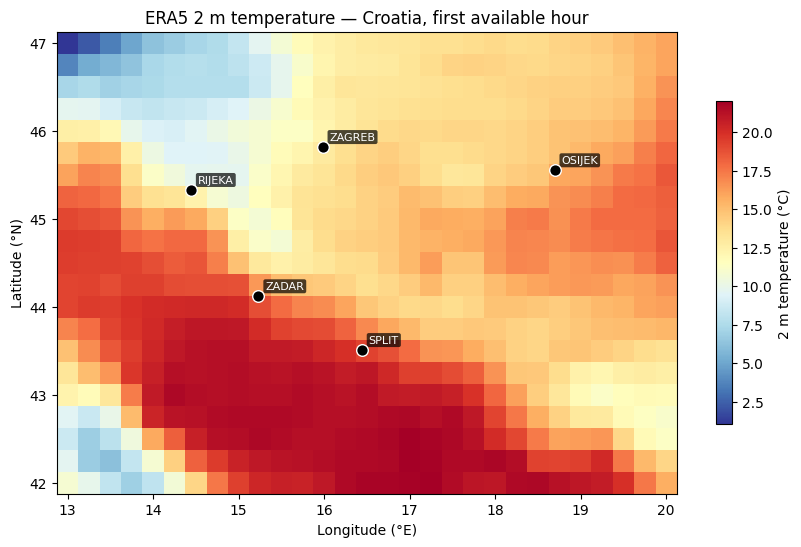

In [10]:
temp_var = next((v for v in era5.data_vars if v in ("t2m", "2t")), None)
if temp_var is None:
    temp_var = list(era5.data_vars)[0]

time_dim = "valid_time" if "valid_time" in era5.dims else "time"
t = era5[temp_var].isel({time_dim: 0})

units = era5[temp_var].attrs.get("units", "?")
if units == "K":
    t_plot = t - 273.15
    cbar_label = "2 m temperature (°C)"
else:
    t_plot = t
    cbar_label = f"{temp_var} ({units})"

stations = rxp.load_stations("../../data/stations_example.csv")

fig, ax = plt.subplots(figsize=(10, 6))
t_plot.plot(
    ax=ax, cmap="RdYlBu_r", add_colorbar=True,
    cbar_kwargs={"label": cbar_label, "shrink": 0.7},
)
ax.scatter(
    stations["lon"], stations["lat"],
    color="black", edgecolors="white", s=70, zorder=6,
)
for _, row in stations.iterrows():
    ax.annotate(
        row["location_id"].replace('01', ''), xy=(row["lon"], row["lat"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=8, color="white",
        bbox=dict(boxstyle="round,pad=0.18", fc="black", alpha=0.7, lw=0),
    )
ax.set_title("ERA5 2 m temperature — Croatia, first available hour")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
plt.show()

## Building a Derived Feature — Wind Speed

Machine learning models typically prefer **wind speed** and **wind direction**
to the raw `u10` / `v10` components that ERA5 delivers.

In [11]:
u_name = next((v for v in era5.data_vars if v in ("u10", "10u")), None)
v_name = next((v for v in era5.data_vars if v in ("v10", "10v")), None)

if u_name and v_name:
    u = era5[u_name]
    v = era5[v_name]

    wind_speed = np.sqrt(u ** 2 + v ** 2)
    wind_speed.attrs["units"] = "m s-1"
    wind_speed.attrs["long_name"] = "10 m wind speed"

    wind_dir = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0
    wind_dir.attrs["units"] = "deg"
    wind_dir.attrs["long_name"] = "10 m wind direction (from)"

    era5["wind_speed_10m"] = wind_speed
    era5["wind_dir_10m"] = wind_dir

    print(
        f"Wind speed range: {float(wind_speed.min()):.2f} – "
        f"{float(wind_speed.max()):.2f} m/s"
    )
else:
    print("u10 / v10 not present — skipping derived wind features.")

Wind speed range: 0.01 – 13.85 m/s


## Extracting Reanalysis Values at the Station Locations

This section uses `reanalysis_extract_points.py`. The two methods it offers are:

- **`extract_nearest`** - selects the single closest grid cell.
- **`extract_bilinear`** - interpolates between the four surrounding cells.

For continuous fields (temperature, wind, pressure), **bilinear** is the
default: it smooths out grid-cell boundaries. For discontinuous or
accumulated fields (precipitation totals, boundary layer height over
complex terrain), prefer **nearest** so that you do not invent values
the model never produced.

In [13]:
stations = rxp.load_stations("../../data/stations_example.csv")
stations

,location_id,station_name,lat,lon,country
0,ZAGREB01,Zagreb,45.8150,15.9819,HR
1,SPLIT01,Split,43.5081,16.4402,HR
2,RIJEKA01,Rijeka,45.3271,14.4422,HR
3,OSIJEK01,Osijek,45.5511,18.6939,HR
4,ZADAR01,Zadar,44.1194,15.2314,HR


In [12]:
era5_vars = [
    v for v in era5.data_vars
    if v not in (u_name, v_name, "wind_dir_10m")
]
print("Extracting variables:", era5_vars)

near_df = rxp.extract_nearest(
    ds=era5,
    variables=era5_vars,
    stations=stations,
)
near_df.head(12)

Extracting variables: ['t2m', 'd2m', 'sp', 'blh', 'tp', 'wind_speed_10m']


,time,location_id,lat,lon,variable,value,source,method,dataset_version
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,t2m,286.131104,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
1,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,t2m,292.437744,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
2,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,t2m,285.521729,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
3,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,t2m,289.076416,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,t2m,292.013916,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
5,2024-06-01 01:00:00,ZAGREB01,45.8150,15.9819,t2m,285.663818,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
6,2024-06-01 01:00:00,SPLIT01,43.5081,16.4402,t2m,292.236084,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
7,2024-06-01 01:00:00,RIJEKA01,45.3271,14.4422,t2m,285.238037,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
8,2024-06-01 01:00:00,OSIJEK01,45.5511,18.6939,t2m,288.003662,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
9,2024-06-01 01:00:00,ZADAR01,44.1194,15.2314,t2m,291.273193,reanalysis,nearest,history=2026-05-20T14:24 GRIB to CDM+CF via cf...


In [13]:
bilin_df = rxp.extract_bilinear(
    ds=era5,
    variables=era5_vars,
    stations=stations,
)
bilin_df.head(12)

,time,location_id,lat,lon,variable,value,source,method,dataset_version
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,t2m,285.867271,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
1,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,t2m,292.513107,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
2,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,t2m,284.916519,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
3,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,t2m,288.607564,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,t2m,290.975509,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
5,2024-06-01 01:00:00,ZAGREB01,45.8150,15.9819,t2m,285.381687,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
6,2024-06-01 01:00:00,SPLIT01,43.5081,16.4402,t2m,292.243565,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
7,2024-06-01 01:00:00,RIJEKA01,45.3271,14.4422,t2m,284.682293,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
8,2024-06-01 01:00:00,OSIJEK01,45.5511,18.6939,t2m,287.777111,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
9,2024-06-01 01:00:00,ZADAR01,44.1194,15.2314,t2m,290.484923,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...


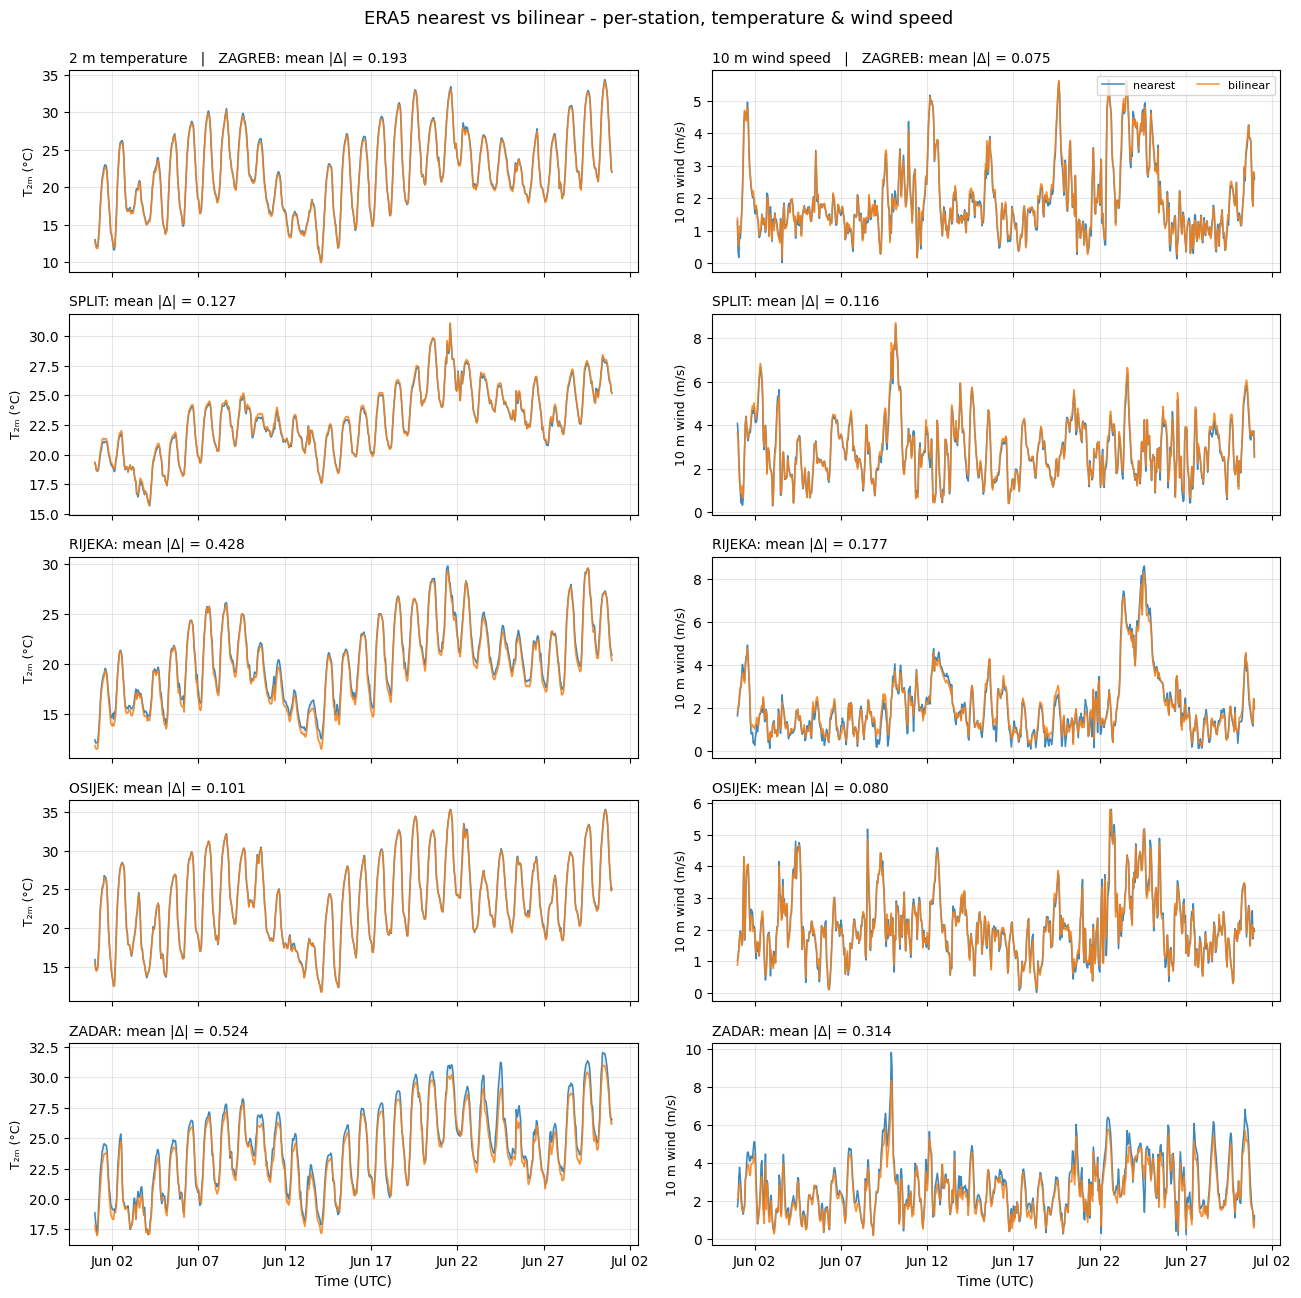

In [14]:
variables_to_compare = [
    ("t2m",            "T₂ₘ (°C)",        lambda s: s - 273.15),  # K → °C
    ("wind_speed_10m", "10 m wind (m/s)", lambda s: s),
]
col_titles = ["2 m temperature", "10 m wind speed"]
stations_order = stations["location_id"].tolist()

fig, axes = plt.subplots(
    len(stations_order), 2,
    figsize=(13, 13),
    sharex=True,
)
fig.suptitle(
    "ERA5 nearest vs bilinear - per-station, temperature & wind speed",
    fontsize=13, y=0.995,
)

for row, loc in enumerate(stations_order):
    for col, (var, ylabel, transform) in enumerate(variables_to_compare):
        ax = axes[row, col]

        near = (
            near_df[(near_df["location_id"] == loc) & (near_df["variable"] == var)]
            .sort_values("time")
        )
        bili = (
            bilin_df[(bilin_df["location_id"] == loc) & (bilin_df["variable"] == var)]
            .sort_values("time")
        )

        near_y = transform(near["value"].astype(float).values)
        bili_y = transform(bili["value"].astype(float).values)

        ax.plot(near["time"], near_y, color="tab:blue",
                linewidth=1.1, alpha=0.85, label="nearest")
        ax.plot(bili["time"], bili_y, color="tab:orange",
                linewidth=1.1, alpha=0.85, label="bilinear")
        ax.fill_between(near["time"].values, near_y, bili_y,
                        color="grey", alpha=0.15)

        mad = float(np.nanmean(np.abs(near_y - bili_y)))
        prefix = f"{col_titles[col]}   |   " if row == 0 else ""
        ax.set_title(
            f"{prefix}{loc.replace('01', '')}: mean |Δ| = {mad:.3f}",
            fontsize=10, loc="left",
        )

        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 1:
            ax.legend(loc="upper right", fontsize=8, ncol=2)

for ax in axes[-1, :]:
    ax.set_xlabel("Time (UTC)")
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()


## Composition Reanalysis - The CAMS PM₂.₅ File

The CAMS European AQ file already available in this project is the
**composition** half of the reanalysis story. The same extractor operates
on it: the file has the same dimensional structure (`time`, `latitude`,
`longitude`, and optionally `level`).

In [15]:
cams = _load_data(CAMS_PATH)
print("Before fix:", cams["time"].values)

cams = rxp.fix_cams_time(cams, base_date="2024-06-15") # Fixing timestamps
print("After fix: ", cams["time"].values)

Before fix: ['2024-06-01T00:00:00.000000000' '2024-06-01T01:00:00.000000000'
 '2024-06-01T02:00:00.000000000' '2024-06-01T03:00:00.000000000'
 '2024-06-01T04:00:00.000000000' '2024-06-01T05:00:00.000000000'
 '2024-06-01T06:00:00.000000000' '2024-06-01T07:00:00.000000000'
 '2024-06-01T08:00:00.000000000' '2024-06-01T09:00:00.000000000'
 '2024-06-01T10:00:00.000000000' '2024-06-01T11:00:00.000000000'
 '2024-06-01T12:00:00.000000000' '2024-06-01T13:00:00.000000000'
 '2024-06-01T14:00:00.000000000' '2024-06-01T15:00:00.000000000'
 '2024-06-01T16:00:00.000000000' '2024-06-01T17:00:00.000000000'
 '2024-06-01T18:00:00.000000000' '2024-06-01T19:00:00.000000000'
 '2024-06-01T20:00:00.000000000' '2024-06-01T21:00:00.000000000'
 '2024-06-01T22:00:00.000000000' '2024-06-01T23:00:00.000000000'
 '2024-06-02T00:00:00.000000000' '2024-06-02T01:00:00.000000000'
 '2024-06-02T02:00:00.000000000' '2024-06-02T03:00:00.000000000'
 '2024-06-02T04:00:00.000000000' '2024-06-02T05:00:00.000000000'
 '2024-06-02T

In [17]:
cams_var = "pm2p5"

cams_df = rxp.extract_bilinear(
    ds=cams,
    variables=cams_var,
    stations=stations,
    source="CAMS European AQ analysis",
)
cams_df

,time,location_id,lat,lon,variable,value,source,method,dataset_version
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.518890,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
1,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,pm2p5,7.192024,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
2,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,pm2p5,3.180345,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
3,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,pm2p5,4.511617,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,pm2p5,5.501490,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
...,...,...,...,...,...,...,...,...,...
3595,2024-06-30 23:00:00,ZAGREB01,45.8150,15.9819,pm2p5,10.727150,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
3596,2024-06-30 23:00:00,SPLIT01,43.5081,16.4402,pm2p5,11.234119,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
3597,2024-06-30 23:00:00,RIJEKA01,45.3271,14.4422,pm2p5,13.032470,CAMS European AQ analysis,bilinear,Conventions=CF-1.7
3598,2024-06-30 23:00:00,OSIJEK01,45.5511,18.6939,pm2p5,12.464704,CAMS European AQ analysis,bilinear,Conventions=CF-1.7


## Aligning ERA5 onto the CAMS Time Axis

ERA5 and the CAMS European reanalysis are both hourly over the same
month, so this alignment is effectively a 1:1 join every CAMS hour
finds its exact ERA5 match. 

In [18]:
era5_aligned = rxp.align_to_reference(
    bilin_df,
    reference_times=cams_df["time"].unique(),
    tolerance="1h",
    method="nearest",
)

print(f"ERA5 rows before alignment: {len(bilin_df)}")
print(f"ERA5 rows after alignment:  {len(era5_aligned)}")
print()
print("Distinct timestamps now:")
for t in sorted(era5_aligned["time"].unique()):
    print(f"  {pd.Timestamp(t)}")

ERA5 rows before alignment: 21600
ERA5 rows after alignment:  21600

Distinct timestamps now:
  2024-06-01 00:00:00
  2024-06-01 01:00:00
  2024-06-01 02:00:00
  2024-06-01 03:00:00
  2024-06-01 04:00:00
  2024-06-01 05:00:00
  2024-06-01 06:00:00
  2024-06-01 07:00:00
  2024-06-01 08:00:00
  2024-06-01 09:00:00
  2024-06-01 10:00:00
  2024-06-01 11:00:00
  2024-06-01 12:00:00
  2024-06-01 13:00:00
  2024-06-01 14:00:00
  2024-06-01 15:00:00
  2024-06-01 16:00:00
  2024-06-01 17:00:00
  2024-06-01 18:00:00
  2024-06-01 19:00:00
  2024-06-01 20:00:00
  2024-06-01 21:00:00
  2024-06-01 22:00:00
  2024-06-01 23:00:00
  2024-06-02 00:00:00
  2024-06-02 01:00:00
  2024-06-02 02:00:00
  2024-06-02 03:00:00
  2024-06-02 04:00:00
  2024-06-02 05:00:00
  2024-06-02 06:00:00
  2024-06-02 07:00:00
  2024-06-02 08:00:00
  2024-06-02 09:00:00
  2024-06-02 10:00:00
  2024-06-02 11:00:00
  2024-06-02 12:00:00
  2024-06-02 13:00:00
  2024-06-02 14:00:00
  2024-06-02 15:00:00
  2024-06-02 16:00:00
  20

## Building the Joint Predictor Table

Stack the ERA5 and CAMS long rows, then pivot to wide format so that each row
represents one `(time, location_id)` and each column represents one variable.
This is the table shape that a machine learning pipeline expects.

In [19]:
combined_long = pd.concat([era5_aligned, cams_df], ignore_index=True)

wide = (
    combined_long
    .pivot_table(
        index=["time", "location_id", "lat", "lon"],
        columns="variable",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)
wide.columns.name = None
wide

,time,location_id,lat,lon,blh,d2m,pm2p5,sp,t2m,tp,wind_speed_10m
0,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,53.547312,287.945847,4.511617,99849.159319,288.607564,0.000000,0.874448
1,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,203.930549,283.793603,3.180345,95189.377304,284.916519,0.000448,1.821627
2,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,292.782244,290.233756,7.192024,98282.845689,292.513107,0.000271,3.662241
3,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,146.076319,288.017408,5.501490,99788.944013,290.975509,0.000227,2.066118
4,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,259.557787,285.592837,4.518890,98562.004560,285.867271,0.000000,1.389644
...,...,...,...,...,...,...,...,...,...,...,...
3595,2024-06-30 23:00:00,OSIJEK01,45.5511,18.6939,91.660846,294.187139,12.464704,99892.879623,298.118659,0.000000,1.971380
3596,2024-06-30 23:00:00,RIJEKA01,45.3271,14.4422,136.177429,291.282795,13.032470,95597.647714,293.480030,0.000000,1.963105
3597,2024-06-30 23:00:00,SPLIT01,43.5081,16.4402,203.154616,292.440821,11.234119,98466.989236,298.324066,0.000000,2.536038
3598,2024-06-30 23:00:00,ZADAR01,44.1194,15.2314,32.166885,293.203277,13.038596,100055.597376,299.341303,0.000000,0.910998


## Saving the Canonical Long-Format Table

In [20]:
out_csv = rtt.write_canonical_output(
    extracted_df=combined_long,
    ds=era5,
    variables=era5_vars + [cams_var],
    method="bilinear (ERA5) + bilinear (CAMS)",
    output_csv="../../data/outputs/reanalysis_features.csv",
)

print(f"Wrote: {out_csv}")
print(f"Wrote: {out_csv.with_suffix('.meta.txt')}")

Wrote: ..\..\data\outputs\reanalysis_features.csv
Wrote: ..\..\data\outputs\reanalysis_features.meta.txt


In [21]:
final = pd.read_csv("../../data/outputs/reanalysis_features.csv")
print(f"Rows: {len(final)}   Columns: {list(final.columns)}")
final.head(10)

Rows: 25200   Columns: ['time', 'location_id', 'lat', 'lon', 'variable', 'value', 'source', 'method', 'dataset_version']


,time,location_id,lat,lon,variable,value,source,method,dataset_version
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,t2m,285.867271,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
1,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,tp,0.000448,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
2,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,tp,0.000271,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
3,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,tp,0.000000,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,blh,146.076319,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
5,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,blh,53.547312,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
6,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,blh,203.930549,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
7,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,blh,292.782244,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
8,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,blh,259.557787,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...
9,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,wind_speed_10m,1.389644,reanalysis,bilinear,history=2026-05-20T14:24 GRIB to CDM+CF via cf...


## Recap

You have now completed the reanalysis-to-station pipeline:

1. Downloaded ERA5 hourly meteorology over Croatia from the Climate
   Data Store.
2. Opened the NetCDF file and inspected its dimensions, variables, and attributes.
3. Visualised a continuous meteorological field and confirmed that it appears sensible.
4. Engineered a derived feature (wind speed) on the grid.
5. Extracted values at the five Croatian stations using **nearest** and
   **bilinear** interpolation, then compared the two methods.
6. Re-read the CAMS PM₂.₅ file from Part 1 as the *composition* side
   of the reanalysis pair, correcting its non-CF time axis.
7. Intersected the dense ERA5 axis onto the sparser CAMS timestamps so that
   the two could be joined on `(time, location_id)`.
8. Saved the combined long-format table with a provenance sidecar,
   ready for the next module.

**Next:** in the integration module, this reanalysis feature
table is merged with ground-station PM₂.₅ measurements, and a first baseline
model is trained.